In [10]:
# SVM Tutorial in Python

# --- 1. Importing Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [14]:

# --- 2. Load Dataset ---
# We'll use sklearn's built-in iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # take only first two features for easy visualization
y = iris.target

In [15]:
X.shape

(150, 2)

In [16]:
y.shape

(150,)

In [17]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 3. Train SVM Classifier ---
svm_model = SVC(kernel='linear', C=100)
svm_model.fit(X_train, y_train)


SVC(C=100, kernel='linear')

In [28]:

# --- 4. Predictions ---
y_pred = svm_model.predict(X_test)

# --- 5. Evaluation ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45



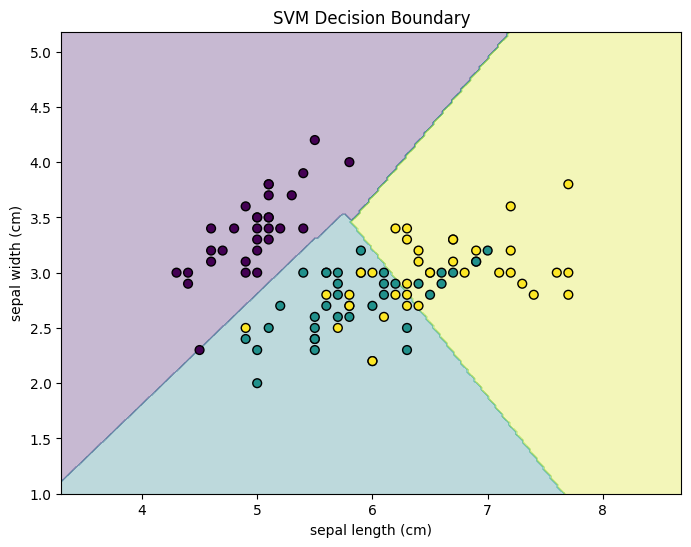

In [21]:

# --- 6. Visualization ---
def plot_svm_decision_boundary(model, X, y):
    plt.figure(figsize=(8,6))
    h = .02  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolors='k')
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title("SVM Decision Boundary")
    plt.show()

plot_svm_decision_boundary(svm_model, X_train, y_train)


Kernel: linear
Accuracy: 0.8
-


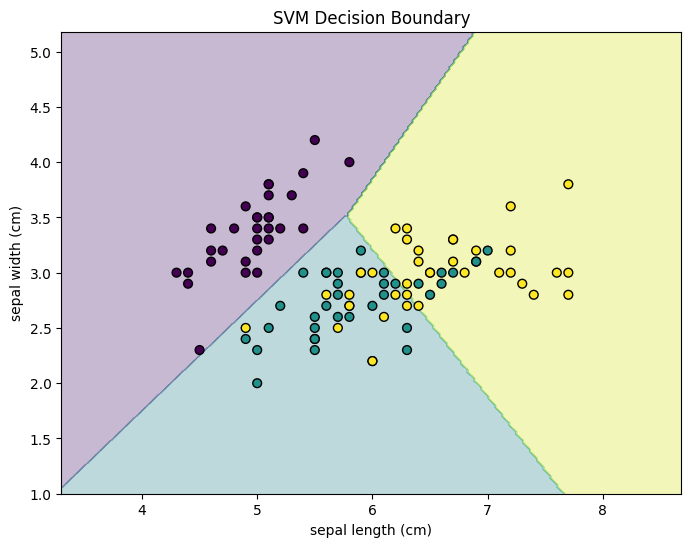

Kernel: poly
Accuracy: 0.7777777777777778
-


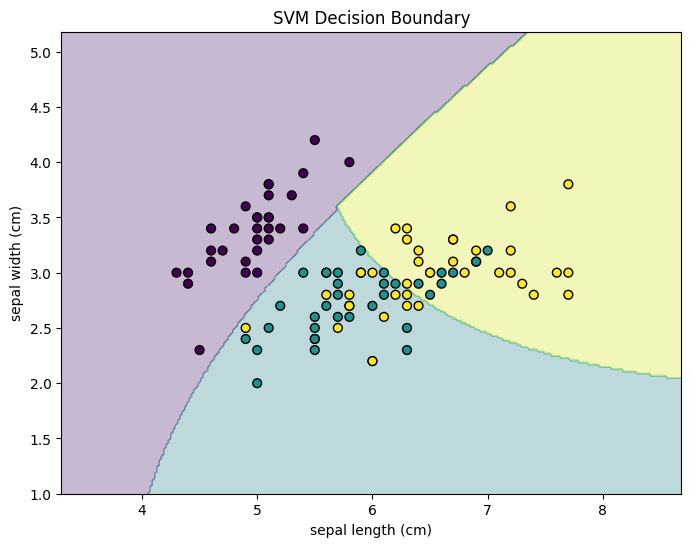

Kernel: rbf
Accuracy: 0.8
-


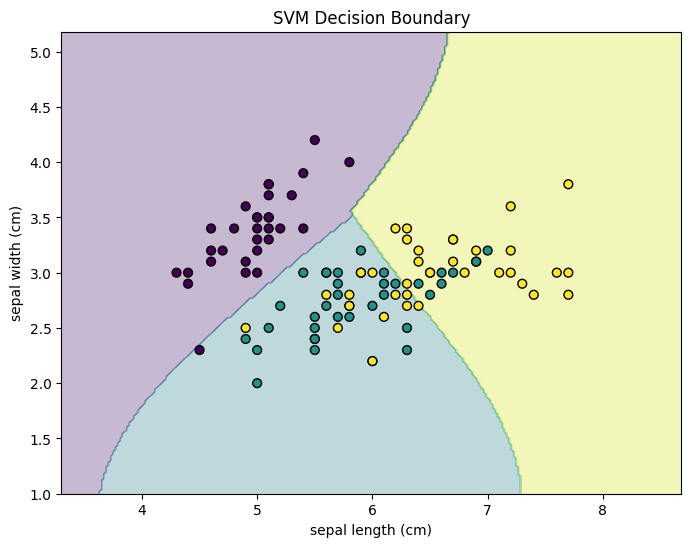

Kernel: sigmoid
Accuracy: 0.35555555555555557
-


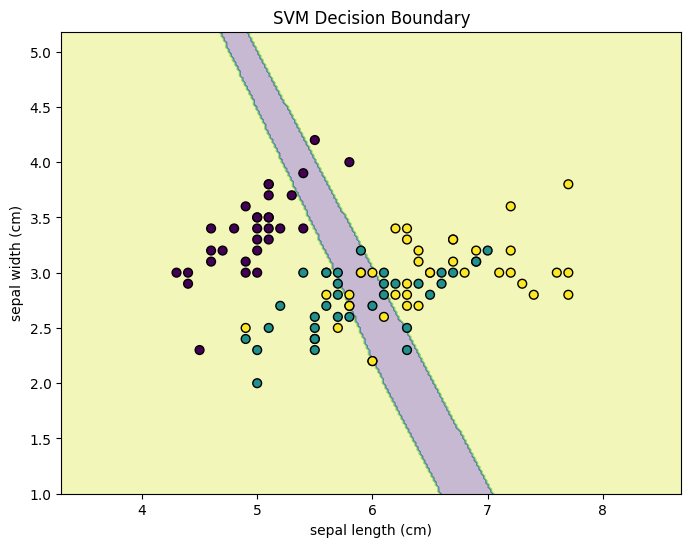

In [22]:

# --- 7. Try Different Kernels ---
for kernel in ["linear", "poly", "rbf", "sigmoid"]:
    clf = SVC(kernel=kernel, C=1.0, gamma='auto')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"Kernel: {kernel}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-")
    plot_svm_decision_boundary(clf, X_train, y_train)


In [ ]:
# 100 - 1 100 - 0

# 2 -> 1 PL ; 2 -> 1 TL  

# precision 100 ; R very low

# 100 - 1 100 - 0

# 200 -> 1
 
# recall 1 ; precision very low

# f1 = HM of P & R

In [ ]:
precision = tp / tp + fp
recall = tp / tp + fn
f1 

In [7]:

# --- 8. Hyperparameter Tuning with GridSearch ---
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score: 0.8285714285714285


In [8]:

# --- 9. Final Model Evaluation ---
final_model = grid.best_estimator_
y_pred_final = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred_final))


Final Accuracy: 0.8222222222222222


In [9]:

# --- 10. Exercise ---
# TODO: Try changing dataset (e.g. sklearn.datasets.make_moons or digits)
# TODO: Experiment with different kernels, C values, and gamma
# TODO: Visualize decision boundary for different feature pairs
